In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
np.random.seed(12)

In [2]:
# Defining the Gaussian kernel function
def _kernel(grid):
    return np.exp(-1*(grid**2)/2)

In [3]:
# Defining some samples
Xgrid = np.linspace(0, 1, 500)
sN = np.array([0.548, 0.823, 1.0])
sP = np.array([0.0, 0.14])

Text(0.5, 1.0, "SciPy's Scott")

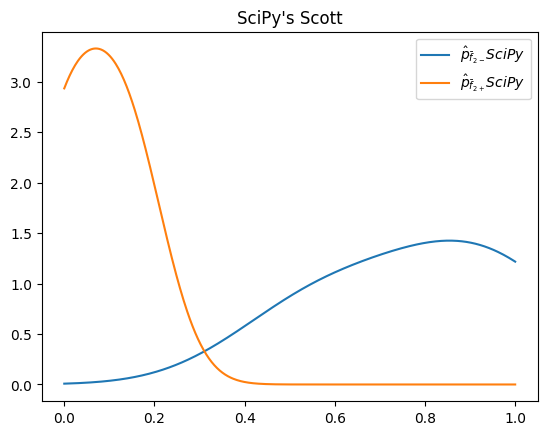

In [4]:
# Scipy's built-in KDE (Scott)
pde_scipyN = np.reshape(gaussian_kde(sN)(Xgrid).T, Xgrid.shape)
pde_scipyP = np.reshape(gaussian_kde(sP)(Xgrid).T, Xgrid.shape)
plt.plot(Xgrid, pde_scipyN, label=r"$\hat{p}_{\bar{f}_{2-}} SciPy$")
plt.plot(Xgrid, pde_scipyP, label=r"$\hat{p}_{\bar{f}_{2+}} SciPy$")
plt.legend()
plt.title("SciPy's Scott")

Text(0.5, 1.0, 'SciPy + Own Scott')

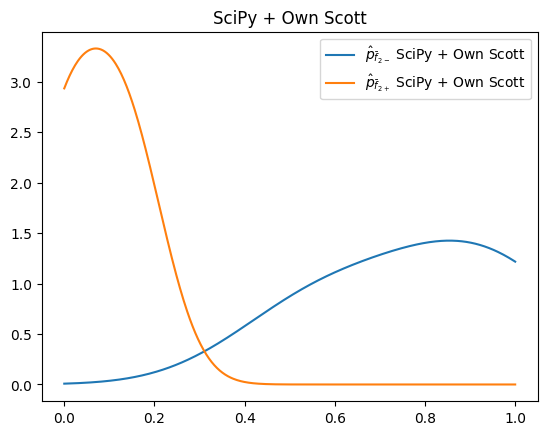

In [5]:
# Integrating (own) Scott into SciPy's gaussian_kde
def compute_scott_bw(_sample):
    bw = len(_sample)**(-1/5)
    return bw

# Construct KDE for negative samples
kde_scipyN_ownScott = gaussian_kde(sN, bw_method=compute_scott_bw(sN))

# Construct KDE for positive samples
kde_scipyP_ownScott = gaussian_kde(sP, bw_method=compute_scott_bw(sP))

pde_scipyN_ownScott = np.reshape(kde_scipyN_ownScott(Xgrid).T, Xgrid.shape)
pde_scipyP_ownScott = np.reshape(kde_scipyP_ownScott(Xgrid).T, Xgrid.shape)

plt.plot(Xgrid, pde_scipyN_ownScott, label=r"$\hat{p}_{\bar{f}_{2-}}$ SciPy + Own Scott")
plt.plot(Xgrid, pde_scipyP_ownScott, label=r"$\hat{p}_{\bar{f}_{2+}}$ SciPy + Own Scott")
plt.legend()
plt.title("SciPy + Own Scott")

## Testing ProD

In [6]:
from prod_fs import ProD
from sklearn.datasets import make_classification

# Create random classification dataset
X, y = make_classification(
    n_samples=300, n_features=50, n_classes=3, n_informative=5,
    shuffle=False, random_state=0
)

In [7]:
# Initialize ProD object
prodRanker_customScott = ProD(bw_method="customScott", bw_factor=None)
prodRanker_scipyScott = ProD(bw_method="scott", bw_factor=None)

# Carry out feature selection
prodRanker_customScott.fit(X, y)
prodRanker_scipyScott.fit(X, y)

Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'
Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'


In [8]:
def check_ranker(ranker):
    # Get top 10 features
    top10Features = ranker.get_topnFeatures(10)
    
    # Visualize the top feature's ability to segregate PDEs
    fig, axs = plt.subplots(1, 2, sharey=True)
    
    # Top ranked feature
    ranker.plot_overlapAreas(top10Features[0], legend="intersection", _ax=axs[0])
    axs[0].set_title("Most relevant feature", loc="left")
    
    # Last ranked feature
    ranker.plot_overlapAreas(49, legend="intersection", _ax=axs[1])
    axs[1].set_title("Least relevant feature", loc="left")
    
    axs[0].set_ylabel(r"Probability Density, $\hat{P}$")
    for i in range(2):
        axs[i].set_xlim(-0.5, 1.5)
        axs[i].set_xticks(np.arange(-0.5, 2.0, 0.5))

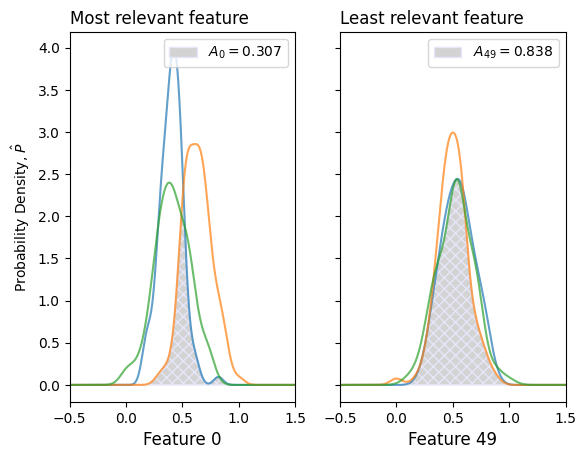

In [9]:
check_ranker(prodRanker_customScott)

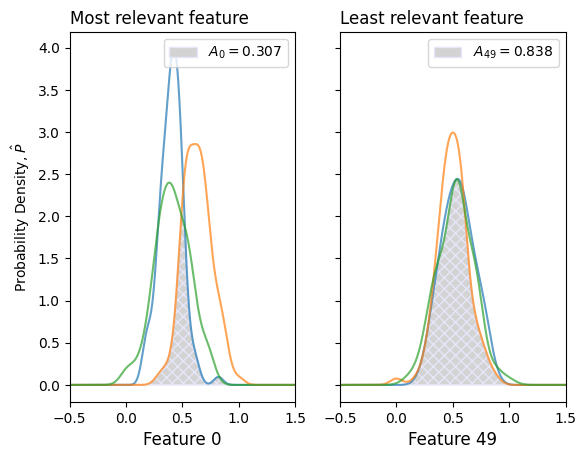

In [10]:
check_ranker(prodRanker_scipyScott)

## Testing custom bandwidth rule of thumbs with user-defined factor

In [11]:
prodRanker_customScott01 = ProD(bw_method="customScott", bw_factor=0.1)
prodRanker_customScott1 = ProD(bw_method="customScott", bw_factor=None)
prodRanker_customScott10 = ProD(bw_method="customScott", bw_factor=10)

prodRanker_customScott01.fit(X, y)
prodRanker_customScott1.fit(X, y)
prodRanker_customScott10.fit(X, y)

Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'
Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'
Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'


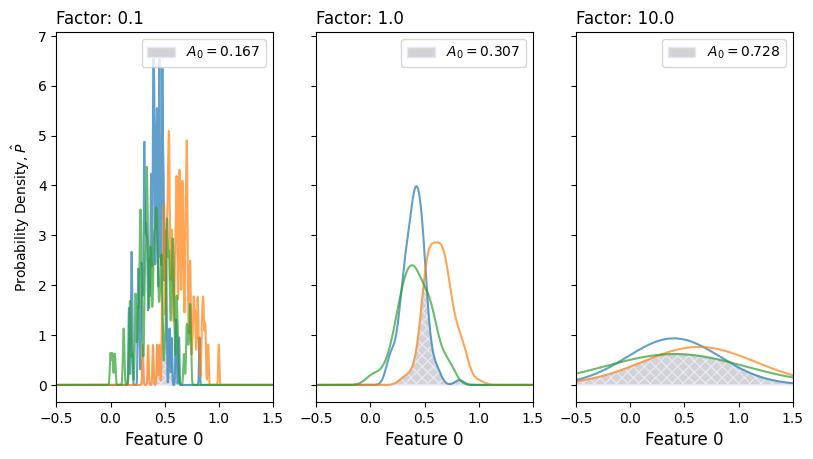

In [12]:
top10Features = prodRanker_customScott1.get_topnFeatures(10)

# Visualize the top feature's ability to segregate PDEs
fig, axs = plt.subplots(1, 3, sharey=True, figsize=(9.5, 4.8))

# Top ranked feature
prodRanker_customScott01.plot_overlapAreas(top10Features[0], legend="intersection", _ax=axs[0])
axs[0].set_title("Factor: 0.1", loc="left")

prodRanker_customScott1.plot_overlapAreas(top10Features[0], legend="intersection", _ax=axs[1])
axs[1].set_title("Factor: 1.0", loc="left")

prodRanker_customScott10.plot_overlapAreas(top10Features[0], legend="intersection", _ax=axs[2])
axs[2].set_title("Factor: 10.0", loc="left")


axs[0].set_ylabel(r"Probability Density, $\hat{P}$")
for i in range(3):
    axs[i].set_xlim(-0.5, 1.5)
    axs[i].set_xticks(np.arange(-0.5, 2.0, 0.5))